# Partial Differential Equations Part I. 

There are [3 broad classes of PDEs](https://en.wikiversity.org/wiki/Partial_differential_equations#Elliptic,_Hyperbolic,_and_Parabolic_PDEs): hyperbolic, elliptic, and parabolic PDEs.  

## Types of PDEs
```{note} PDE nomenclature
We can write PDEs in the general form:
$$a\phi_{xx} + b\phi_{xy} + c\phi_{yy} + d\phi_{x} + e\phi_{y} + f\phi = g$$

The naming convention is analogous to that of conic sections, where the PDE is:
+ Hyperbolic if $b^2 - 4ac > 0$
+ Parabolic  if $b^2 - 4ac = 0$
+ Elliptic   if  $b^2 - 4ac > 0$

Notation note:  
$$\frac{\partial^2 f}{\partial x^2} = \frac{\partial}{\partial x}\frac{\partial f}{\partial x} \equiv \frac{\partial f}{\partial x} / {\partial x} \equiv f_{xx}.$$

```

Different types of PDEs will each require different solution methods.


### Hyperbolic PDEs

The canonical hyperbolic PDE is the *wave equation*:

$$\frac{\partial^2 \phi}{\partial t^2} = c^2 \frac{\partial^2 \phi}{\partial x^2}$$

The solution to this is traveling waves moving at speed $c$ in both directions:

$$\phi(x, t) = A f_0(x - ct) + B g_0(x + ct)$$

Another example is the  _linear advection equation_, commonly employed in fluid dynamics problems:

$$\frac{\partial a}{\partial t} + u \frac{\partial a}{\partial x} = 0$$

The defining feature of hyperbolic PDEs is that there is a finite, real speed at which the solution changes.
Solutions have distinct propagation speeds and typically require both initial and boundary conditions.


### Elliptic PDEs

The *Poisson equation* is the canonical elliptic PDE:

$$\nabla^2 \phi = f$$

Notice that there is no time variable here! 
 
Information about the solution moves at infinite speed, and the solution depends only on the boundary conditions and the source, $f$.

In physics, the Poisson equation is commonly used to obtain the gravitational potential $\Phi(r)$ of a mass distributed according to density $\rho(r)$, via [Poisson's equation](https://en.wikipedia.org/wiki/Poisson%27s_equation#Newtonian_gravity)

$$\nabla^2 \Phi = 4 \pi G \rho$$

Solutions are therefore static and require boundary conditions defined on all sides.

### Parabolic PDEs

The *diffusion equation* is the canonical parabolic PDE:

$$\frac{\partial \phi}{\partial t} = \frac{\partial^2 (K \phi)}{\partial x^2}$$

As with elliptic PDEs, information about the solution is communicated instantaneously; there is no finite propagate speed like the hyperbolic case.
But the solution is time-dependent. Solutions typically smooth out sharp features over time. 

## Boundary Value Problem PDEs
We can also classify PDEs in terms of initial value (IVP) vs. boundary value (BVP) problems. Today we'll primarily talk about BVPs. 
 
Some typical types of boundary conditions are:
+ Dirichlet (specify value at the boundary)
+ Neumann (specify the derivative normal to the boundary) 
+ Periodic (function values must be equal at periodic boundaries)

When solving ODEs, we primarily discretized across one independent variable (time or space). Due to the nature of PDE problems, we now typically need to discretize both *space* and *time* (or even multiple space dimensions).

For this purpose, there are many different types of spatial discretization: 
+ Finite difference
+ Finite volume
+ Finite element 
+ Spectral
+ Particle methods 

### Finite Difference
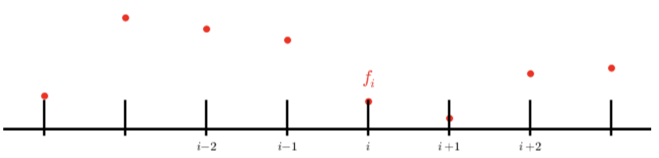

In the finite difference approach:
+ function values are stored at discrete grid points. 
+ derivatives in the PDE are replaced with discrete differences between neighboring grid points
 
Most of the ODEs we've solved already have employed finite difference for discretization in time. 

### Finite Volume
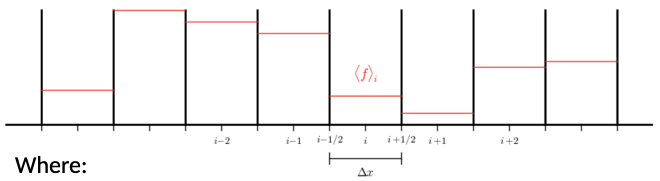

In the finite volume approach:
+ the average of the function value $f$ over the grid interval is stored at each "cell":
$$\langle f\rangle_i = \frac{1}{\Delta x} \int_{x_{i-1/2}}^{x_{i+1/2}} f(x) \, dx$$
+ half-integers are used to label the boundaries of the cells

Finite volume is a natural discretezation for PDEs in [conservation law form](https://en.wikipedia.org/wiki/Conservation_form):
$$\frac{\partial \xi}{\partial t} + \nabla \cdot \mathbf{f}(\xi) = 0$$

for a conserved quantity $\xi$, by Gauss's Theorem, we can write the same expression in integral form over a control volume $V$:
$$\frac{d}{dt}\int_{V} \xi \; dV = - \oint_{\partial V} \mathbf{f}(\xi) \cdot \hat{n} \, dS$$

where ${\bf f(\xi)}$ is the flux of the quantity through the surface boundary of $V$. 

## Example: Laplace's Equation

Laplace's equation describes the electric potential $\phi$, for an electric field is described by $E = -\Delta \phi$ in the absence of any charges:

$$ \nabla^2 \phi = 0 $$

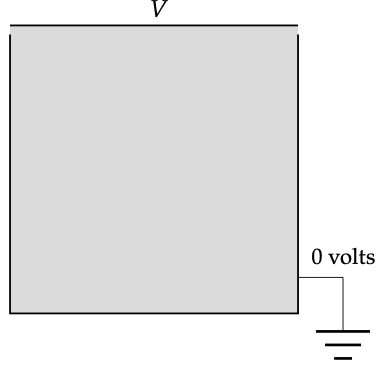

Let’s say  we have an empty box with voltage $\phi = V$ on the top side and $\phi = 0$ on all the other sides for the two dimensional Laplace Equation:

$$\frac{\partial^2 \phi}{\partial x^2} + \frac{\partial^2 \phi}{\partial y^2} = 0$$

We need to solve for $\phi(x,y)$. 

:question
```{embed} ex_8-1
```

```{embed} sol_8-1
```

### Discretization
We need to translate this PDE into numerical form. 
+ Let's start by discretizing in both spatial dimensions, defining a grid in $x$ and $y$:  
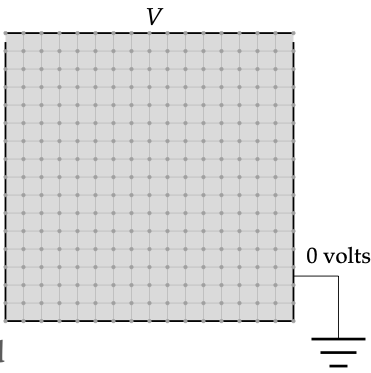

+ Then on the grid we need to define how a derivative works. Let's use *finite differences*, defining the derivative as we did in [week 4](./4b_derivatives.ipynb). 
    +  We'll define the first derivative as a *centered difference*, which defines it at the midpoint between two grid points:
        $$f'_{i+1/2} = \frac{f_{i+1} - f_i}{\Delta x}$$
    + Then, if we take a centered difference again to get the second derivative it will be on the grid:
        $$f''_i = \frac{f'_{i+1/2} - f'_{i-1/2}}{\Delta x}$$

```{note} Second-Derivative Centered Differences
$$ f''_i = \frac{f_{i+1} - 2f_i + f_{i-1}}{\Delta x^2}$$

Recall, this is a second-order accurate scheme:
$$\varepsilon = \frac{4C|f(x)|}{h^{2}} + \frac{1}{12} h^{2} |f'''(x)|$$
```

We can define this for the function $\phi(x,y)$ for each dimension, for a grid discretized such that points in $x$ are separated by $\Delta x$ and points in y by $\Delta y$. It's a simpler problem to solve for a uniform grid where $\Delta x = \Delta y = a$, where the Laplacian operator becomes:

$$\frac{\partial^2 \phi}{\partial x^2} + \frac{\partial^2 \phi}{\partial y^2} = \frac{\phi(x + a, y) + \phi(x - a, y) + \phi(x, y + a) + \phi(x, y - a) - 4\phi(x, y)}{a^{2}} $$

Since $\nabla^2 \phi = 0$, Laplace's Equation is reduced to:

$$\phi(x + a, y) + \phi(x - a, y) + \phi(x, y + a) + \phi(x, y - a) - 4\phi(x, y) = 0$$

In order to solve across our entire grid, we have to solve a system of equations: the above equation for every $(x,y)$ point in the grid. 
Thus, for a $20 \times 20$ grid, we solve $400$ equations.

In this form, we can see that we can solve this for any method we've used for [solving systems of equations](./5_setup.md): LU decomposition, Gaussian elimination, etc.


### Solution by Relaxation (Jacobi Method)
We can also relaxation, which we've used for non-linear equations, but we can see also works here,  where we can rearrange the equation into the form: 
$$\phi(x,y) = \frac{1}{4}\big[\phi(x+a,y) + \phi(x-a,y) + \phi(x,y+a) + \phi(x,y-a)\big]$$

Funnily enough -- remember that all we've done is define a series of numerical derivatives for Laplace's equation -- we can see that the bounds on the solution for Laplace's equation is that the value of a function at a point is the average of all it's surrounding grid points. Math is weird. 

```{note} Relaxation Reminder
:class: dropdown
Recall: the relaxation method requires an equation of the form:
$$f(x) = x$$

Now might be a good time to revisit the algorithm for [relaxation](#relaxation)
```

To use relaxation, we'll start from some initial guesses for $\phi_i(x,y)$ at every point (using our boundary conditions where appropriate). 
Then we'll iterate to find an improved value: $\phi_{i+1}(x,y) = \frac{1}{4}\big[\phi_i(x+a,y) + \phi_i(x-a,y) + \phi_i(x,y+a) + \phi_i(x,y-a)\big]$ until the differences between iterations are minimized to our target accuracy. 

<h2><span class="fa fa-flash"></span> In-Class Coding Exercise </h2>

```{embed} icc_8-1
```

:question

```{embed} ex_8-2
```



## Modifications on Jacobi Method
Since the scaling for the Jacobi Method goes with the size of the grid, this method can be incredibly slow or memory intensive for large enough grids.
We can apply some modifications which can improve the efficiency of relaxation method.

### Gauss-Seidel
Instead of looping through an array of $\phi_i$ to determine the next guess $\phi_{i+1}$ at all points, we can update the values on the grid as we go. Thus, the next iteration for the value at $\phi_{i+1}(x+a,y)$ will be calculated using the updated (and presumably more accurate) value of $\phi_{i+1}(x,y)$. 
This has the added bonus of only needing to store a single array of values on the grid, instead of two arrays for the current and next iteration. 

<h2><span class="fa fa-flash"></span> In-Class Coding Exercise </h2>

```{embed} icc_8-2
```

### Overrelaxation
Recall, that overrelaxation takes the original form of relaxation, which defines the next iteration as:
$$\phi_{i+1}(x,y) = \phi_i(x,y) + \Delta\phi_i(x,y)$$
"overshoots" the definition of the next iteration:
$$\phi_{w, i+1}(x,y) = \phi_i(x,y) + (1 + w)\Delta\phi_i(x,y)$$
parameterized by some factor $w$, such that:

$$\phi_{w,i+1}(x,y) = \frac{1 + w}{4} \left[ \phi_i(x + a, y) + \phi_i(x - a, y) + \phi_i(x, y + a) + \phi_i(x, y - a) \right] - w\phi_i(x,y)$$ 


```{tip} Choosing $w$
Typically, the exact choice of $w$ is a matter of trial and error, but the general rule of thumb is that for:
$|w| > 1$, the solution will be **unstable**. 
```

```{warning} Overrelaxation + Jacobi
It turns out that overrelaxation is *numerically unstable* with the Jacobi method alone, but stable when used with Gauss-Seidel method. 
```

<h2><span class="fa fa-flash"></span> In-Class Coding Exercise </h2>

```{embed} icc_8-3
```